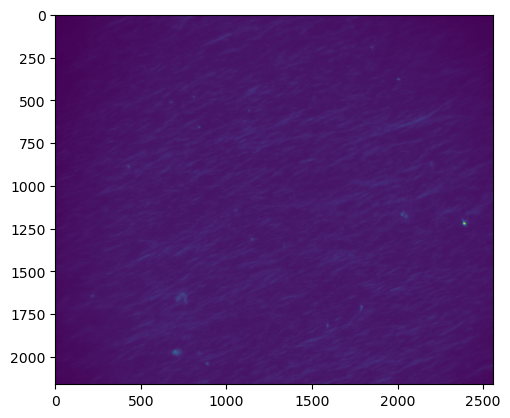

In [23]:
import matplotlib.pyplot as plt
import zarr
import pandas
import cv2
import numpy as np
from pathlib import Path
from skimage import filters

folder = Path("/Volumes/data/Sasaki/MTsingleBeads/beads06um/20260716/beads06um003")

#folder = Path("/mnt/NAS-Ebanaru/sasaki/MTsingleBeads/beads5um/20260616/beads5um001_crop")

MTs_file = folder / "GFP.zarr"
beads_file = folder / "beads.zarr"
track_file = folder / 'beads_tracks.csv'

MTs = zarr.open_array(MTs_file, mode='r')
beads = zarr.open_array(beads_file, mode='r')

plt.imshow(MTs[0], vmin=MTs[0].min(), vmax = MTs[0].max())

In [24]:
# beads_tracksを読み込む
tracks_df = pandas.read_csv(track_file)
print(f"Tracks shape: {tracks_df.shape}")
print(f"Columns: {tracks_df.columns.tolist()}")


Tracks shape: (2112, 10)
Columns: ['y', 'x', 'mass', 'size', 'ecc', 'signal', 'raw_mass', 'ep', 'frame', 'particle']


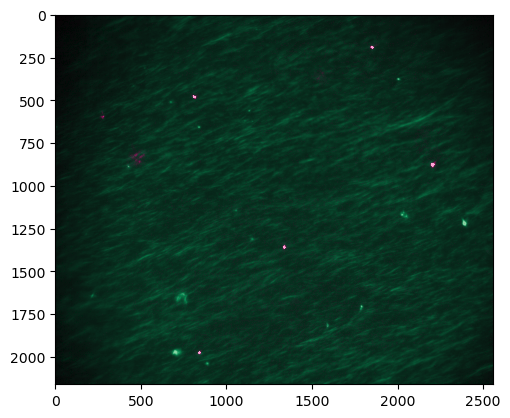

In [25]:
from matplotlib.colors import LinearSegmentedColormap
import matplotlib.colors as mcolors

gfp_base = mcolors.to_rgb("#00A960")  # (0.0, 0.663, 0.376)

cud_gfp_cmap = mcolors.LinearSegmentedColormap.from_list(
    "cud_gfp",
    [
        (0.0, (0.0, 0.0, 0.0, 1.0)),              # 輝度0: 完全透明な黒
        (0.7, (gfp_base[0], gfp_base[1], gfp_base[2], 1.0)), # 輝度70%: 純粋なCUD緑（半透明）
        (1.0, (0.6, 1.0, 0.75, 1.0))              # 輝度100%: 芯が光るエメラルドホワイト（不透明）
    ]
)

beads_base = mcolors.to_rgb("#E4007F")  # (0.894, 0.0, 0.498)

cud_magenta_cmap = mcolors.LinearSegmentedColormap.from_list(
    "cud_magenta",
    [
        (0.0, (0.0, 0.0, 0.0, 0.0)),                  # 輝度0: 完全透明な黒
        (0.7, (beads_base[0], beads_base[1], beads_base[2], 0.7)), # 輝度70%: 純粋なCUDマゼンタ（半透明）
        (1.0, (1.0, 0.65, 0.85, 1.0))                  # 輝度100%: 芯が光るパステルマゼンタホワイト（不透明）
    ]
)
MTs_max_factor = 0.3
beads_max_factor = 0.15

# 図を2つ並べて表示する場合
fig, ax = plt.subplots()
# 最初のプロット：MTs
ax.imshow(MTs[0], cmap=cud_gfp_cmap, vmin=MTs[0].min(), vmax = MTs[0].max()*MTs_max_factor)

# 2番目のプロット：beads（マスク付き）
ax.imshow(beads[0], cmap=cud_magenta_cmap, interpolation="nearest", vmin=beads[0].min(), vmax = beads[0].max()*beads_max_factor)

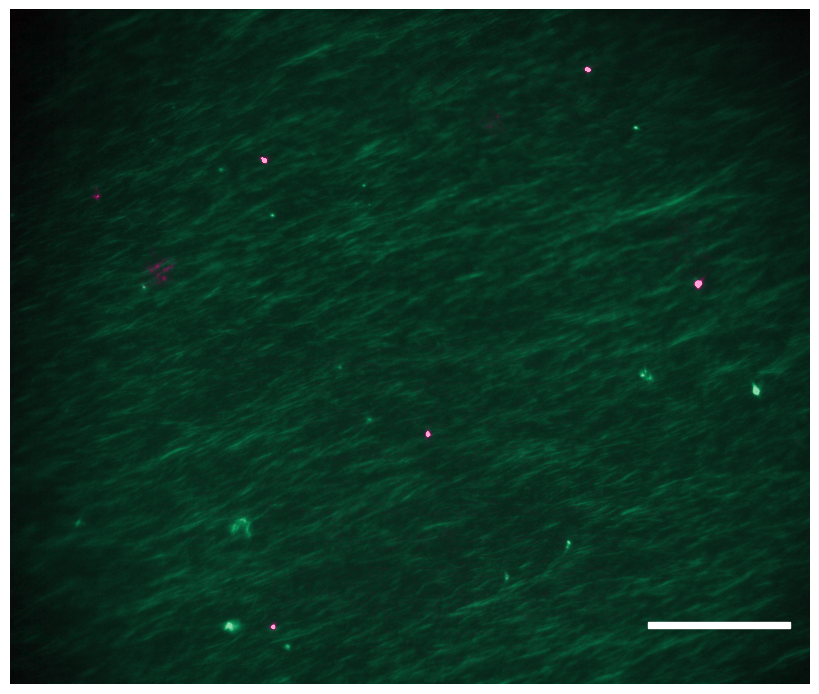

In [26]:
from matplotlib.animation import FuncAnimation
import numpy as np
from mpl_toolkits.axes_grid1.anchored_artists import AnchoredSizeBar
import matplotlib.font_manager as fm
import matplotlib.pyplot as plt # 必要に応じて

plasma = plt.cm.plasma
plasma_cmap = LinearSegmentedColormap.from_list(
    "plasma_bright",
    plasma(np.linspace(0.3, 1, 256))
)

scale = 0.11
n_frames = MTs.shape[0]

# ==========================================
# 修正ポイント1: 画像の縦横比（ピクセル数）に合わせてFigureを作成
# ==========================================
height, width = MTs[0].shape
fig, ax = plt.subplots(figsize=(8, 8 * (height / width)))

# vmin/vmax固定
bead_vmin = beads[0].min()
bead_vmax = beads[0].max() * beads_max_factor

# 画像
im1 = ax.imshow(MTs[0], cmap=cud_gfp_cmap, animated=True, vmin=MTs[0].min(), vmax=MTs[0].max()*MTs_max_factor)
im2 = ax.imshow(beads[0],
                cmap=cud_magenta_cmap,
                interpolation="nearest",
                animated=True,
                vmin=bead_vmin,
                vmax=bead_vmax)

from matplotlib.collections import LineCollection

# 軌跡を線で描画するためのLineCollection
lc = LineCollection([], cmap=plasma_cmap, norm=plt.Normalize(0, 1), animated=True, linewidths=2)
ax.add_collection(lc)

# ==========================================
# 修正ポイント2: 軸と余白の完全な無効化（固定）
# ==========================================
ax.axis('off')
ax.set_position([0, 0, 1, 1]) # AxesをFigure全体に限界まで広げる
fig.subplots_adjust(left=0.0, right=1.0, bottom=0.0, top=1.0)

fontprops = fm.FontProperties(size=24)
size_bar = AnchoredSizeBar(ax.transData,
                           size=50/scale,
                           label='',
                           loc=4,
                           pad=0.5,
                           color='white',
                           frameon=False,
                           size_vertical=20,
                           fontproperties=fontprops)
ax.add_artist(size_bar)

def update_frame(frame):
    im1.set_array(MTs[frame])
    im2.set_array(beads[frame])

    current_tracks = tracks_df[tracks_df['frame'] <= frame]

    if len(current_tracks) > 0:
        segments = []
        colors = []
        for particle_id, group in current_tracks.groupby('particle'):
            x = group['x'].values
            y = group['y'].values
            t = group['frame'].values / n_frames
            
            pts = np.array([x, y]).T.reshape(-1, 1, 2)
            if len(pts) > 1:
                segs = np.concatenate([pts[:-1], pts[1:]], axis=1)
                segments.extend(segs)
                colors.extend(t[1:])
                
        lc.set_segments(segments)
        lc.set_array(np.array(colors))

    return im1, im2, lc

anim = FuncAnimation(fig, update_frame,
                     frames=n_frames,
                     interval=100,
                     blit=True, repeat=True)


In [27]:
#anim.save("/Users/sasakinozomu/Desktop/anim.mp4", savefig_kwargs={"pad_inches": 0, "bbox_inches": "tight"})
anim.save(str(folder / "anim.mp4"), savefig_kwargs={"pad_inches": 0, "bbox_inches": "tight"})

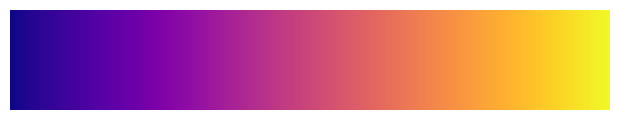

In [9]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np

# 動画内での時間の最小値と最大値（例: 0秒から100秒）
vmin = 0
vmax = 100

fig, ax = plt.subplots(figsize=(6, 1))  # 横長の図を作成
fig.subplots_adjust(bottom=0.5)

# カラーマップと正規化
cmap = plt.get_cmap('plasma')
norm = mcolors.Normalize(vmin=vmin, vmax=vmax)

# カラーバーを作成（水平方向）
cbar = fig.colorbar(plt.cm.ScalarMappable(norm=norm, cmap=cmap),
                    cax=ax, orientation='horizontal')
cbar.set_label('Time (s)') # 単位に合わせてラベルを変更してください

plt.axis("off")
plt.subplots_adjust(left=0.0, right=1.0, bottom=0.0, top=1.0)

#plt.title('Time Colorbar')
plt.show()

# 必要であれば保存します
fig.savefig('/Users/sasakinozomu/Desktop/colorbar.pdf', bbox_inches='tight')
